# PBC3.py test

In [1]:
%load_ext autoreload
%autoreload 2

from PBC3 import PBC3, PBC3Config
from PBC2_4 import PBC as PBC2
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
import os
import time
import io
from pbc3_debug_patch import install_debug_patch

PBC3 = install_debug_patch(PBC3)

from PBC3_animation import animate_pbc3

TEST_IMAGES_DIR = "test_images"
TEST_IMAGES = [os.path.join(TEST_IMAGES_DIR, f) for f in os.listdir(TEST_IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
HPT_DATA_DIR = "hpt_data"
HPT_DATA_DIRS = [os.path.join(HPT_DATA_DIR, d) for d in os.listdir(HPT_DATA_DIR) if os.path.isdir(os.path.join(HPT_DATA_DIR, d))]
HPT_DATA_IMAGES = {d.split('/')[-1]: [os.path.join(d, f) for f in os.listdir(d) if f.lower().endswith(('.png', '.jpg', '.jpeg'))] for d in HPT_DATA_DIRS}
HPT_DATA_ALL_IMAGES = [img for sublist in HPT_DATA_IMAGES.values() for img in sublist]
ALL_IMAGES = TEST_IMAGES + HPT_DATA_ALL_IMAGES

In [2]:
def show_debug_candidates(PBC3, debug_text, original_image=None, data=None):
    lines = [line.strip() for line in debug_text.strip().splitlines() if line.strip()]
    parsed = [PBC3.parse_debug_line(line) for line in lines]
    parsed = [(line, d) for line, d in zip(lines, parsed) if d]

    candidates = [(line, d) for line, d in parsed if d.get("kind") == "CANDIDATE"]
    selected = [(line, d) for line, d in parsed if d.get("kind") == "SELECTED"]

    if not candidates:
        print("No CANDIDATE lines found.")
        return

    selected_d = selected[-1][1] if selected else None

    for i, (line, d) in enumerate(candidates, 1):
        is_selected = False
        if selected_d is not None:
            is_selected = all(
                int(d.get(k, -999999)) == int(selected_d.get(k, -888888))
                for k in ("channel", "x", "y", "w", "h", "cell_size")
            )

        print(
            f"Candidate {i}/{len(candidates)}"
            + ("  <-- SELECTED" if is_selected else "")
            + f" | score={d.get('score')} reduction={d.get('reduction')} bits={d.get('bits')}"
        )

        PBC3.show_debug_line(
            line,
            original_image=original_image,
            data=data,
        )

    if selected:
        print("Selected patch:")
        selected_line = selected[-1][0]
        try:
            PBC3.show_debug_line(
                selected_line,
                original_image=original_image,
                data=data,
            )
        except Exception:
            print(selected_line)
    else:
        print("No SELECTED line found in pasted text.")


def efficiency_score(bpp, mse):
    return 1000 / (bpp * mse + 1e-9)
# Compare with JPEG with matching quality rate (match by file size) and also AVIF by the same metric
# quality helpers match quality levels to rough bpp averages, to help give a starting scale for the matching
def comparison_demo(img, res, search_count=8, verbose=False, show_png_too=False, figsize=(24, 6), tight_layout=True, suptitle_fontsize=16, suptitle_y=1.06):
    BPP_GUIDE = {
        "JPEG": [(1, 0.17), (5, 0.21), (10, 0.29), (20, 0.44), (40, 0.65), (60, 0.85), (80, 1.26), (95, 2.77)],
        "AVIF": [(0, 0.01), (2, 0.02), (5, 0.04), (10, 0.06), (20, 0.12), (40, 0.30), (60, 0.68), (80, 1.16), (95, 2.69)],
    }
    def guess_quality(fmt, target_bpp):
        """Inverse-interpolate the guideline table to pick a starting quality for `target_bpp`."""
        g = BPP_GUIDE[fmt]
        qs = [q for q, _ in g]
        bs = [b for _, b in g]
        if target_bpp <= bs[0]:
            return qs[0]
        if target_bpp >= bs[-1]:
            return qs[-1]
        for i in range(1, len(g)):
            if target_bpp <= bs[i]:
                f = (target_bpp - bs[i - 1]) / (bs[i] - bs[i - 1])
                return int(round(qs[i - 1] + f * (qs[i] - qs[i - 1])))
        return qs[-1]
    
    def match_quality(target_bpp, fmt, search_count=8, verbose=False):
        min_q = 0 if fmt == "AVIF" else 1
        max_q = 95

        def encode_at(q):
            buf = io.BytesIO()
            img.save(buf, format=fmt, quality=int(q))
            data = buf.getvalue()
            bpp = len(data) / (img.width * img.height)
            return q, bpp, data

        lo, hi = min_q, max_q
        best = None

        for _ in range(search_count):
            q = (lo + hi) // 2
            q, bpp, data = encode_at(q)

            err = abs(bpp - target_bpp)
            if best is None or err < best[0]:
                best = (err, q, bpp, data)

            if verbose:
                print(f"{fmt} quality {q} -> bpp {bpp:.5f}, target {target_bpp:.5f}")

            if target_bpp > 0 and err / target_bpp < 0.03:
                break

            if bpp > target_bpp:
                hi = q - 1
            else:
                lo = q + 1

            if lo > hi:
                break

        for q in range(max(min_q, best[1] - 3), min(max_q, best[1] + 3) + 1):
            q, bpp, data = encode_at(q)
            err = abs(bpp - target_bpp)
            if verbose:
                print(f"{fmt} refine quality {q} -> bpp {bpp:.5f}")
            if err < best[0]:
                best = (err, q, bpp, data)

        return best[1], best[2]
    # calculate pbc bpp by dividing the compressed size by the number of pixels in the image
    pbc_bpp = len(res.data) / (img.width * img.height)
    print(f"PBC3 bpp: {pbc_bpp:.4f}")
    plt.figure(figsize=figsize)
    plt.subplot(2, 3, 1)
    plt.title(f"Original Image\n{img.width*img.height*3/1024:.2f} KB")
    plt.imshow(img)
    plt.axis("off")
    # do the same for png
    if show_png_too:
        buf = io.BytesIO()
        t0 = time.time()
        img.save(buf, format="PNG")
        encode_time = time.time() - t0
        buf.seek(0)
        t0 = time.time()
        png_img = Image.open(buf)
        decode_time = time.time() - t0
        png_bpp = len(buf.getvalue()) / (img.width * img.height)
        print(f"PNG bpp: {png_bpp:.4f}")
        plt.subplot(2, 3, 2)
        plt.title(f"PNG ({encode_time:.2f}s - {decode_time:.2f}s)\nbpp: {png_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE (lossless): {np.mean((np.array(img).astype(int) - np.array(png_img).astype(int)) ** 2):.1f}")
        plt.imshow(png_img)
        plt.axis("off")
    # match jpeg
    jpeg_quality, current_jpeg_bpp = match_quality(pbc_bpp, "JPEG", search_count=search_count, verbose=verbose)
    print(f"Matched JPEG quality: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}")
    avif_quality, current_avif_bpp = match_quality(pbc_bpp, "AVIF", search_count=search_count, verbose=verbose)
    print(f"Matched AVIF quality: {avif_quality}, bpp: {current_avif_bpp:.4f}")
    plt.subplot(2, 3, 2 + int(show_png_too))
    res24 = PBC2.compress(img)
    t0 = time.time()
    _ = PBC2.decompress(res24.data)
    decode_time = time.time() - t0
    plt.title(f"PBC2.4 ({res24.encode_seconds:.2f}s - {decode_time:.2f}s)\nbpp: {len(res24.data) / (img.width * img.height):.4f}, size: {len(res24.data) / 1024:.2f} KB\nMSE: {res24.mse:.1f}\nEfficiency Score: {efficiency_score(len(res24.data) / (img.width * img.height), res24.mse):.1f}")
    plt.imshow(res24.image)
    plt.axis("off")
    plt.subplot(2, 3, 3 + int(show_png_too))
    decoded = PBC3.decompress(res.data)
    plt.title(f"PBC3 ({res.encode_seconds:.2f}s - {decoded.encode_seconds:.2f}s)\nbpp: {pbc_bpp:.4f}, size: {len(res.data) / 1024:.2f} KB\nMSE: {res.mse:.1f}\nEfficiency Score: {efficiency_score(pbc_bpp, res.mse):.1f}")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(2, 3, 4 + int(show_png_too))
    buf = io.BytesIO()
    t0 = time.time()
    img.save(buf, format="JPEG", quality=jpeg_quality)
    encode_time = time.time() - t0
    buf.seek(0)
    t0 = time.time()
    jpeg_img = Image.open(buf)
    decode_time = time.time() - t0
    plt.imshow(jpeg_img)
    plt.title(f"JPEG ({encode_time:.2f}s - {decode_time:.2f}s)\nq: {jpeg_quality}, bpp: {current_jpeg_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2):.1f}\nEfficiency Score: {efficiency_score(current_jpeg_bpp, np.mean((np.array(img).astype(int) - np.array(jpeg_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.subplot(2, 3, 5 + int(show_png_too))
    buf = io.BytesIO()
    t0 = time.time()
    img.save(buf, format="AVIF", quality=avif_quality)
    encode_time = time.time() - t0
    buf.seek(0)
    t0 = time.time()
    avif_img = Image.open(buf)
    decode_time = time.time() - t0
    plt.imshow(avif_img)
    plt.title(f"AVIF ({encode_time:.2f}s - {decode_time:.2f}s)\nq: {avif_quality}, bpp: {current_avif_bpp:.4f}, size: {len(buf.getvalue()) / 1024:.2f} KB\nMSE: {np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2):.1f}\nEfficiency Score: {efficiency_score(current_avif_bpp, np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2)):.1f}")
    plt.axis("off")
    plt.suptitle(f"Comparison of PBC3, PBC2.4, JPEG, and AVIF Compression for {img.width}x{img.height} Image", fontsize=suptitle_fontsize, y=suptitle_y)
    if tight_layout:
        plt.tight_layout()
    plt.show()

In [3]:
from PBC3 import PBC3
import numpy as np
res = PBC3.compress("test_images/eiffel.png")   # same image as GOLDEN_FILE
golden = open("GOLDEN_FILE.pbc", "rb").read()
print("BYTE-IDENTICAL:", res.data == golden)

BYTE-IDENTICAL: True


In [4]:
import pbc3_resample
pbc3_resample.compare_with_pil()

numba_available=True trials=300
max_abs_float_diff=1.52588e-05
int16_rint_mismatches=0/3601054 (0.00000%)


(1.52587890625e-05, 0, 3601054)

In [112]:
img = Image.open(ALL_IMAGES[15])
base = dict(patch_count=20, q_init=0.7)

cfgs = {
  "baseline (20)":        dict(**base),
  "isd 10":               dict(**base, init_search_depth=10),
  "isd 7":                dict(**base, init_search_depth=7),
  "isd 5":                dict(**base, init_search_depth=5),
  "isd 30":               dict(**base, init_search_depth=30),
}
for name, kw in cfgs.items():
    r = PBC3.compress(img, **kw)
    print(f"{name:16} MSE={r.mse:7.2f}  KB={len(r.data)/1024:6.2f}  rate={r.compression_rate:5.2f}x  t={r.encode_seconds:5.2f}s  verify={r.verify()}")
    print(f"Efficiency Score: {efficiency_score(len(r.data) / (img.width * img.height), r.mse):.1f}")
    print()

baseline (20)    MSE= 676.18  KB= 12.03  rate=1460.98x  t= 1.86s  verify=True
Efficiency Score: 720.2

isd 10           MSE= 676.18  KB= 12.03  rate=1460.98x  t= 1.56s  verify=True
Efficiency Score: 720.2

isd 7            MSE= 676.18  KB= 12.03  rate=1460.98x  t= 1.34s  verify=True
Efficiency Score: 720.2

isd 5            MSE= 675.30  KB= 12.73  rate=1380.39x  t= 1.20s  verify=True
Efficiency Score: 681.4

isd 30           MSE= 676.18  KB= 12.03  rate=1460.98x  t= 1.67s  verify=True
Efficiency Score: 720.2



Processing test_images/eiffel.png (487x487)
  isd=6 -> MSE: 100.09, BPP: 0.10, Efficiency Score: 102.2
  isd=7 -> MSE: 122.43, BPP: 0.05, Efficiency Score: 150.2
  isd=8 -> MSE: 121.54, BPP: 0.06, Efficiency Score: 149.0
  isd=9 -> MSE: 122.43, BPP: 0.05, Efficiency Score: 150.2

Processing test_images/ducklings.jpg (4240x2832)
  isd=6 -> MSE: 188.62, BPP: 0.00, Efficiency Score: 1084.1
  isd=7 -> MSE: 188.62, BPP: 0.00, Efficiency Score: 1084.1
  isd=8 -> MSE: 188.62, BPP: 0.00, Efficiency Score: 1084.1
  isd=9 -> MSE: 188.62, BPP: 0.00, Efficiency Score: 1084.1

Processing test_images/11.jpg (3576x2384)
  isd=6 -> MSE: 79.09, BPP: 0.00, Efficiency Score: 10764.6
  isd=7 -> MSE: 79.09, BPP: 0.00, Efficiency Score: 10764.6
  isd=8 -> MSE: 75.31, BPP: 0.00, Efficiency Score: 10164.2
  isd=9 -> MSE: 75.31, BPP: 0.00, Efficiency Score: 10164.2

Processing test_images/benchmark.png (850x312)
  isd=6 -> MSE: 663.43, BPP: 0.01, Efficiency Score: 110.0
  isd=7 -> MSE: 663.43, BPP: 0.01, Effic

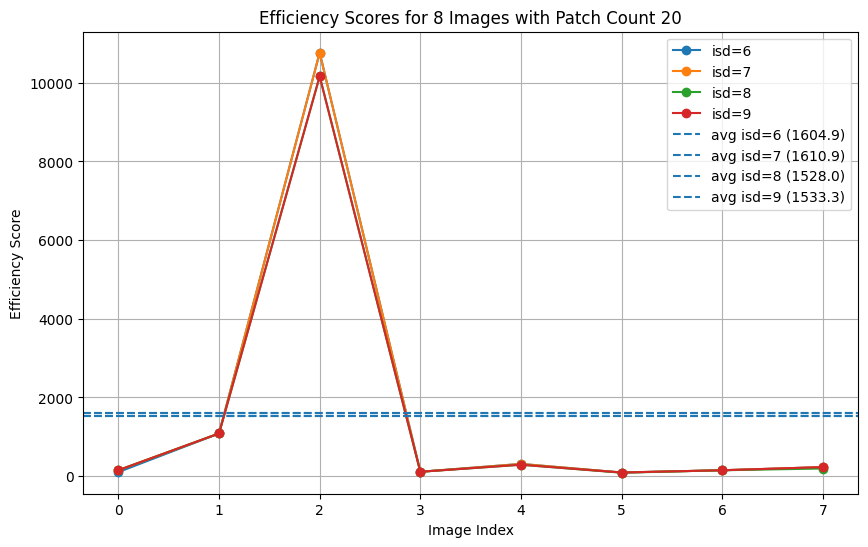

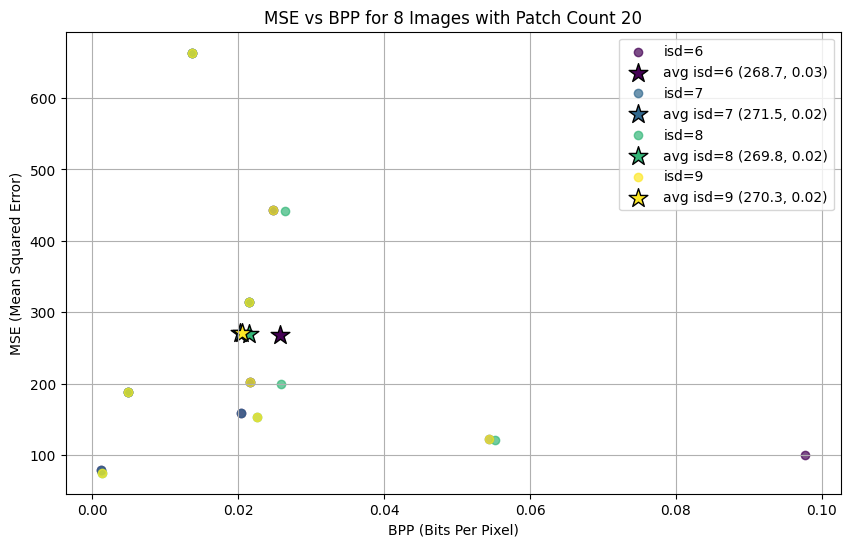

In [116]:
# do the above test but with a bunch of images (n_images from ALL_IMAGES) average out the efficiency scores and plot a graph of efficiency score vs isd for each image, and also plot the average efficiency score across all images for each isd value
n_images = 8
isd_values = [6, 7, 8, 9]
patch_count = 20
efficiency_scores = {q: [] for q in isd_values}
results = {q: [] for q in isd_values}
for img_path in ALL_IMAGES[:n_images]:
    img = Image.open(img_path)
    print(f"Processing {img_path} ({img.width}x{img.height})")
    for isd in isd_values:
        r = PBC3.compress(img, q_init=0.7, patch_count=patch_count, init_search_depth=isd)
        results[isd].append(r)
        score = efficiency_score(len(r.data) / (img.width * img.height), r.mse)
        efficiency_scores[isd].append(score)
        print(f"  isd={isd:.0f} -> MSE: {r.mse:.2f}, BPP: {len(r.data) / (img.width * img.height):.2f}, Efficiency Score: {score:.1f}")
    print()

plt.figure(figsize=(10, 6))
for isd in isd_values:
    plt.plot(range(n_images), efficiency_scores[isd], marker='o', label=f'isd={isd:.0f}')
avg_scores = {q: np.mean(scores) for q, scores in efficiency_scores.items()}
for isd, avg_score in avg_scores.items():
    plt.axhline(y=avg_score, linestyle='--', label=f'avg isd={isd:.0f} ({avg_score:.1f})')
plt.title(f'Efficiency Scores for {n_images} Images with Patch Count {patch_count}')
plt.xlabel('Image Index')
plt.ylabel('Efficiency Score')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
colorlist = plt.cm.viridis(np.linspace(0, 1, len(isd_values)))
for isd in isd_values:
    bpps = [len(r.data) / (Image.open(img_path).width * Image.open(img_path).height) for img_path, r in zip(ALL_IMAGES[:n_images], results[isd])]
    mses = [r.mse for img_path, r in zip(ALL_IMAGES[:n_images], results[isd])]
    plt.scatter(bpps, mses, label=f'isd={isd:.0f}', alpha=0.7, c=[colorlist[isd_values.index(isd)]])
    plt.scatter(np.mean(bpps), np.mean(mses), marker='*', s=200, label=f'avg isd={isd:.0f} ({np.mean(mses):.1f}, {np.mean(bpps):.2f})', edgecolors='black', c=[colorlist[isd_values.index(isd)]])
plt.title(f'MSE vs BPP for {n_images} Images with Patch Count {patch_count}')
plt.xlabel('BPP (Bits Per Pixel)')
plt.ylabel('MSE (Mean Squared Error)')
plt.legend()
plt.grid()
plt.show()

Processing test_images/eiffel.png (487x487)
  q_init=0.60 -> MSE: 122.43, BPP: 0.05, Efficiency Score: 150.2
  q_init=0.65 -> MSE: 122.43, BPP: 0.05, Efficiency Score: 150.2
  q_init=0.70 -> MSE: 122.43, BPP: 0.05, Efficiency Score: 150.2
  q_init=0.75 -> MSE: 118.54, BPP: 0.06, Efficiency Score: 149.7
  q_init=0.80 -> MSE: 99.25, BPP: 0.10, Efficiency Score: 101.0

Processing test_images/ducklings.jpg (4240x2832)
  q_init=0.60 -> MSE: 435.79, BPP: 0.00, Efficiency Score: 1204.5
  q_init=0.65 -> MSE: 434.76, BPP: 0.00, Efficiency Score: 1057.2
  q_init=0.70 -> MSE: 186.90, BPP: 0.01, Efficiency Score: 1037.0
  q_init=0.75 -> MSE: 186.90, BPP: 0.01, Efficiency Score: 1037.0
  q_init=0.80 -> MSE: 178.89, BPP: 0.01, Efficiency Score: 784.3

Processing test_images/11.jpg (3576x2384)
  q_init=0.60 -> MSE: 75.31, BPP: 0.00, Efficiency Score: 10164.2
  q_init=0.65 -> MSE: 75.31, BPP: 0.00, Efficiency Score: 10164.2
  q_init=0.70 -> MSE: 75.31, BPP: 0.00, Efficiency Score: 10164.2
  q_init=0.7

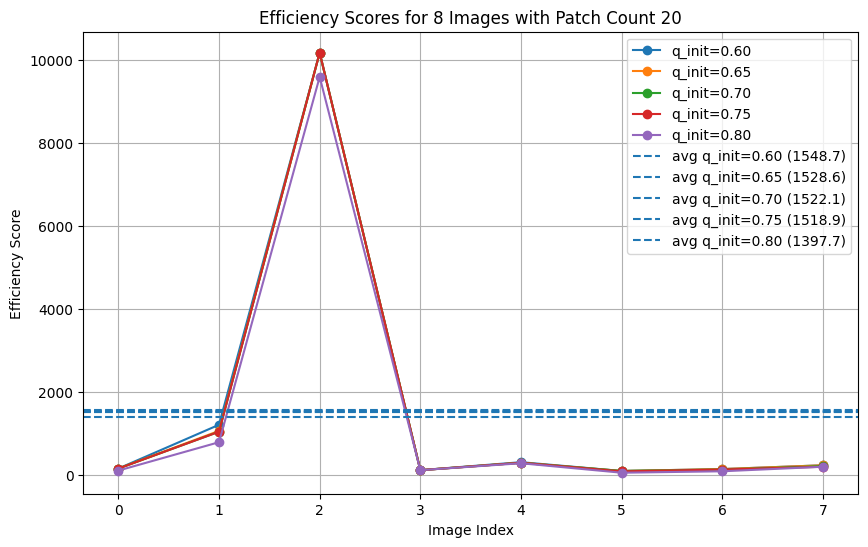

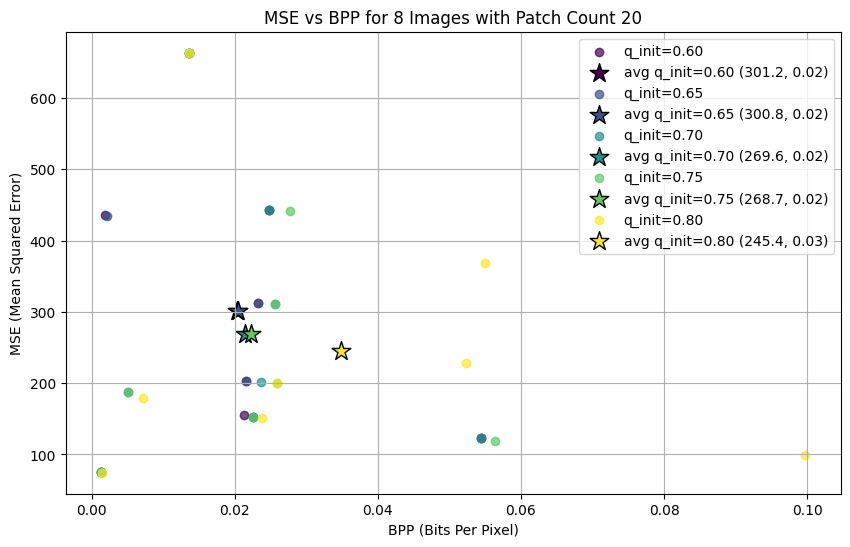

In [110]:
# do the above test but with a bunch of images (n_images from ALL_IMAGES) average out the efficiency scores and plot a graph of efficiency score vs q_init for each image, and also plot the average efficiency score across all images for each q_init value
n_images = 8
q_init_values = [0.6, 0.65, 0.7, 0.75, 0.8]
patch_count = 20
efficiency_scores = {q: [] for q in q_init_values}
results = {q: [] for q in q_init_values}
for img_path in ALL_IMAGES[:n_images]:
    img = Image.open(img_path)
    print(f"Processing {img_path} ({img.width}x{img.height})")
    for q_init in q_init_values:
        r = PBC3.compress(img, patch_count=patch_count, q_init=q_init)
        results[q_init].append(r)
        score = efficiency_score(len(r.data) / (img.width * img.height), r.mse)
        efficiency_scores[q_init].append(score)
        print(f"  q_init={q_init:.2f} -> MSE: {r.mse:.2f}, BPP: {len(r.data) / (img.width * img.height):.2f}, Efficiency Score: {score:.1f}")
    print()

plt.figure(figsize=(10, 6))
for q_init in q_init_values:
    plt.plot(range(n_images), efficiency_scores[q_init], marker='o', label=f'q_init={q_init:.2f}')
avg_scores = {q: np.mean(scores) for q, scores in efficiency_scores.items()}
for q_init, avg_score in avg_scores.items():
    plt.axhline(y=avg_score, linestyle='--', label=f'avg q_init={q_init:.2f} ({avg_score:.1f})')
plt.title(f'Efficiency Scores for {n_images} Images with Patch Count {patch_count}')
plt.xlabel('Image Index')
plt.ylabel('Efficiency Score')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(10, 6))
colorlist = plt.cm.viridis(np.linspace(0, 1, len(q_init_values)))
for q_init in q_init_values:
    bpps = [len(r.data) / (Image.open(img_path).width * Image.open(img_path).height) for img_path, r in zip(ALL_IMAGES[:n_images], results[q_init])]
    mses = [r.mse for img_path, r in zip(ALL_IMAGES[:n_images], results[q_init])]
    plt.scatter(bpps, mses, label=f'q_init={q_init:.2f}', alpha=0.7, c=[colorlist[q_init_values.index(q_init)]])
    plt.scatter(np.mean(bpps), np.mean(mses), marker='*', s=200, label=f'avg q_init={q_init:.2f} ({np.mean(mses):.1f}, {np.mean(bpps):.2f})', edgecolors='black', c=[colorlist[q_init_values.index(q_init)]])
plt.title(f'MSE vs BPP for {n_images} Images with Patch Count {patch_count}')
plt.xlabel('BPP (Bits Per Pixel)')
plt.ylabel('MSE (Mean Squared Error)')
plt.legend()
plt.grid()
plt.show()

In [ ]:
res = PBC3.compress("test_images/benchmark.png", debug_mode=True, debug_path="prof.txt")
print(f"total: {res.encode_seconds:.3f}s")
for line in open("prof.txt"):
    if line.startswith("TIMER"):
        print(line.strip())

total: 0.820s
TIMER phase=setup_downsample seconds=0.010972
TIMER phase=init_layer seconds=0.201776
TIMER phase=visible_error seconds=0.071918
TIMER phase=anchors seconds=0.109002
TIMER phase=search_prescore seconds=0.028985
TIMER phase=mid_score seconds=0.082490
TIMER phase=fill_score seconds=0.282687
TIMER phase=apply_selected seconds=0.013040
TIMER phase=patch_loop_total seconds=0.596086
TIMER phase=serialize seconds=0.003795
TIMER phase=finalize_mse seconds=0.005190
TIMER phase=total seconds=0.819981


[auto-init] channel 0: cell=8, bitcount=5
[auto-init] channel 1: cell=48, bitcount=3
[auto-init] channel 2: cell=48, bitcount=3
||||||||||||||||||||
MSE: 663.5154418945312, Compressed Size: 3.55 KB
Verification successful: Encoded and decoded images are identical.


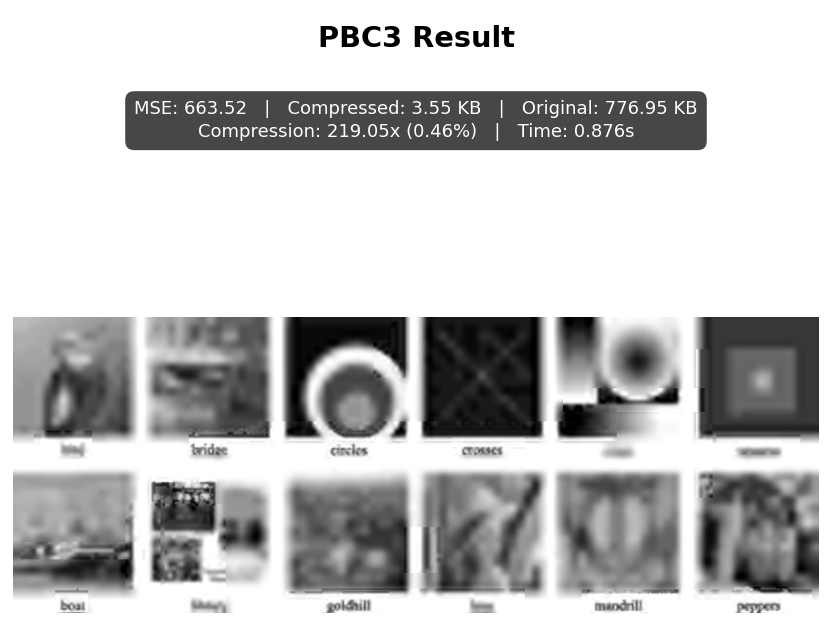

In [20]:
img = Image.open(TEST_IMAGES[3])

cfg = PBC3Config(
    debug_print=True,
)

res = PBC3.compress(img, cfg)

print(f"MSE: {res.mse}, Compressed Size: {len(res.data) / 1024:.2f} KB")
if res.verify():
    print("Verification successful: Encoded and decoded images are identical.")
    res.show()
else:
    print("Verification failed: Encoded and decoded images differ.")
    decoded = PBC3.decompress(res.data)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 3, 1)
    plt.title("Encoded Image")
    plt.imshow(res.image)
    plt.axis("off")
    plt.subplot(1, 3, 2)
    plt.title("Decoded Image")
    plt.imshow(decoded.image)
    plt.axis("off")
    plt.subplot(1, 3, 3)
    plt.title("Difference")
    diff = np.abs(np.array(res.image).astype(float) - np.array(decoded.image).astype(float))
    plt.imshow(diff)
    plt.axis("off")
    plt.show()

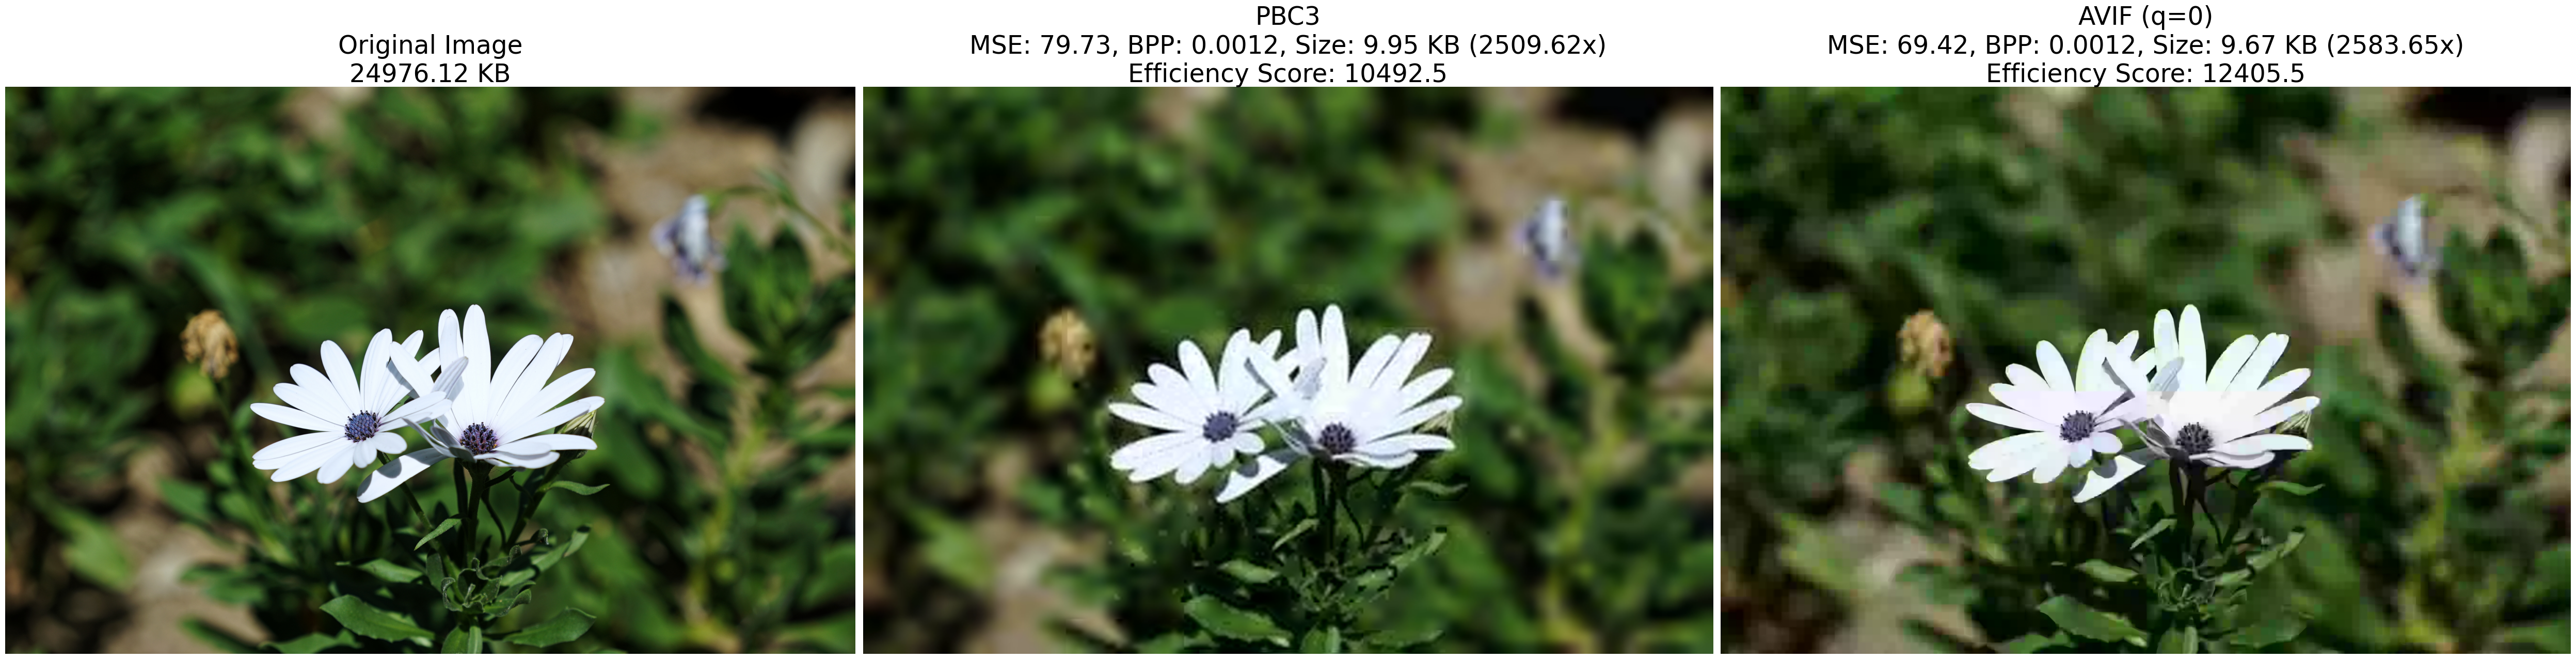

In [15]:
# get avif for the same image and compare to pbc side by side on large canvas where each image is visible fully, show compressed size, bpp and mse for both, as well as the efficiency score for both, and also show the original image for reference
img = Image.open(TEST_IMAGES[2])
pbc3_res = PBC3.compress(img)
buf = io.BytesIO()
quality = 0
img.save(buf, format="AVIF", quality=quality)
avif_data = buf.getvalue()
avif_bpp = len(avif_data) / (img.width * img.height)
avif_img = Image.open(io.BytesIO(avif_data))
pbc3_bpp = len(pbc3_res.data) / (img.width * img.height)
avif_mse = np.mean((np.array(img).astype(int) - np.array(avif_img).astype(int)) ** 2)
plt.figure(figsize=(50, 25))
plt.subplot(1, 3, 1)
plt.title(f"Original Image\n{img.width*img.height*3/1024:.2f} KB", fontsize=35)
plt.imshow(img)
plt.axis("off")
plt.subplot(1, 3, 2)
compression_rate = (img.width * img.height * 3) / len(pbc3_res.data)
plt.title(f"PBC3\nMSE: {pbc3_res.mse:.2f}, BPP: {pbc3_bpp:.4f}, Size: {len(pbc3_res.data)/1024:.2f} KB ({compression_rate:.2f}x)\nEfficiency Score: {efficiency_score(pbc3_bpp, pbc3_res.mse):.1f}", fontsize=35)
plt.imshow(pbc3_res.image)
plt.axis("off")
plt.subplot(1, 3, 3)
compression_rate = (img.width * img.height * 3) / len(avif_data)
plt.title(f"AVIF (q={quality})\nMSE: {avif_mse:.2f}, BPP: {avif_bpp:.4f}, Size: {len(avif_data)/1024:.2f} KB ({compression_rate:.2f}x)\nEfficiency Score: {efficiency_score(avif_bpp, avif_mse):.1f}", fontsize=35)
plt.imshow(avif_img)
plt.axis("off")
plt.tight_layout()
plt.show()

In [53]:
animate_pbc3(
    res.data,
    output_path=f"{img.filename}_pbc.mp4",
    fps=3,
    separated_channels=True,
    show_errors=True,
    original_image=img,
    fallback_to_gif=False,
)

[rawvideo @ 0x124705010] Stream #0: not enough frames to estimate rate; consider increasing probesize
[vost#0:0/libx264 @ 0x124705ff0] Multiple -pix_fmt options specified for stream 0, only the last option '-pix_fmt yuv420p' will be used.


'test_images/ducklings.jpg_pbc.mp4'

PBC3 bpp: 0.0012
PNG bpp: 1.2006
Matched JPEG quality: 1, bpp: 0.0167
Matched AVIF quality: 0, bpp: 0.0012


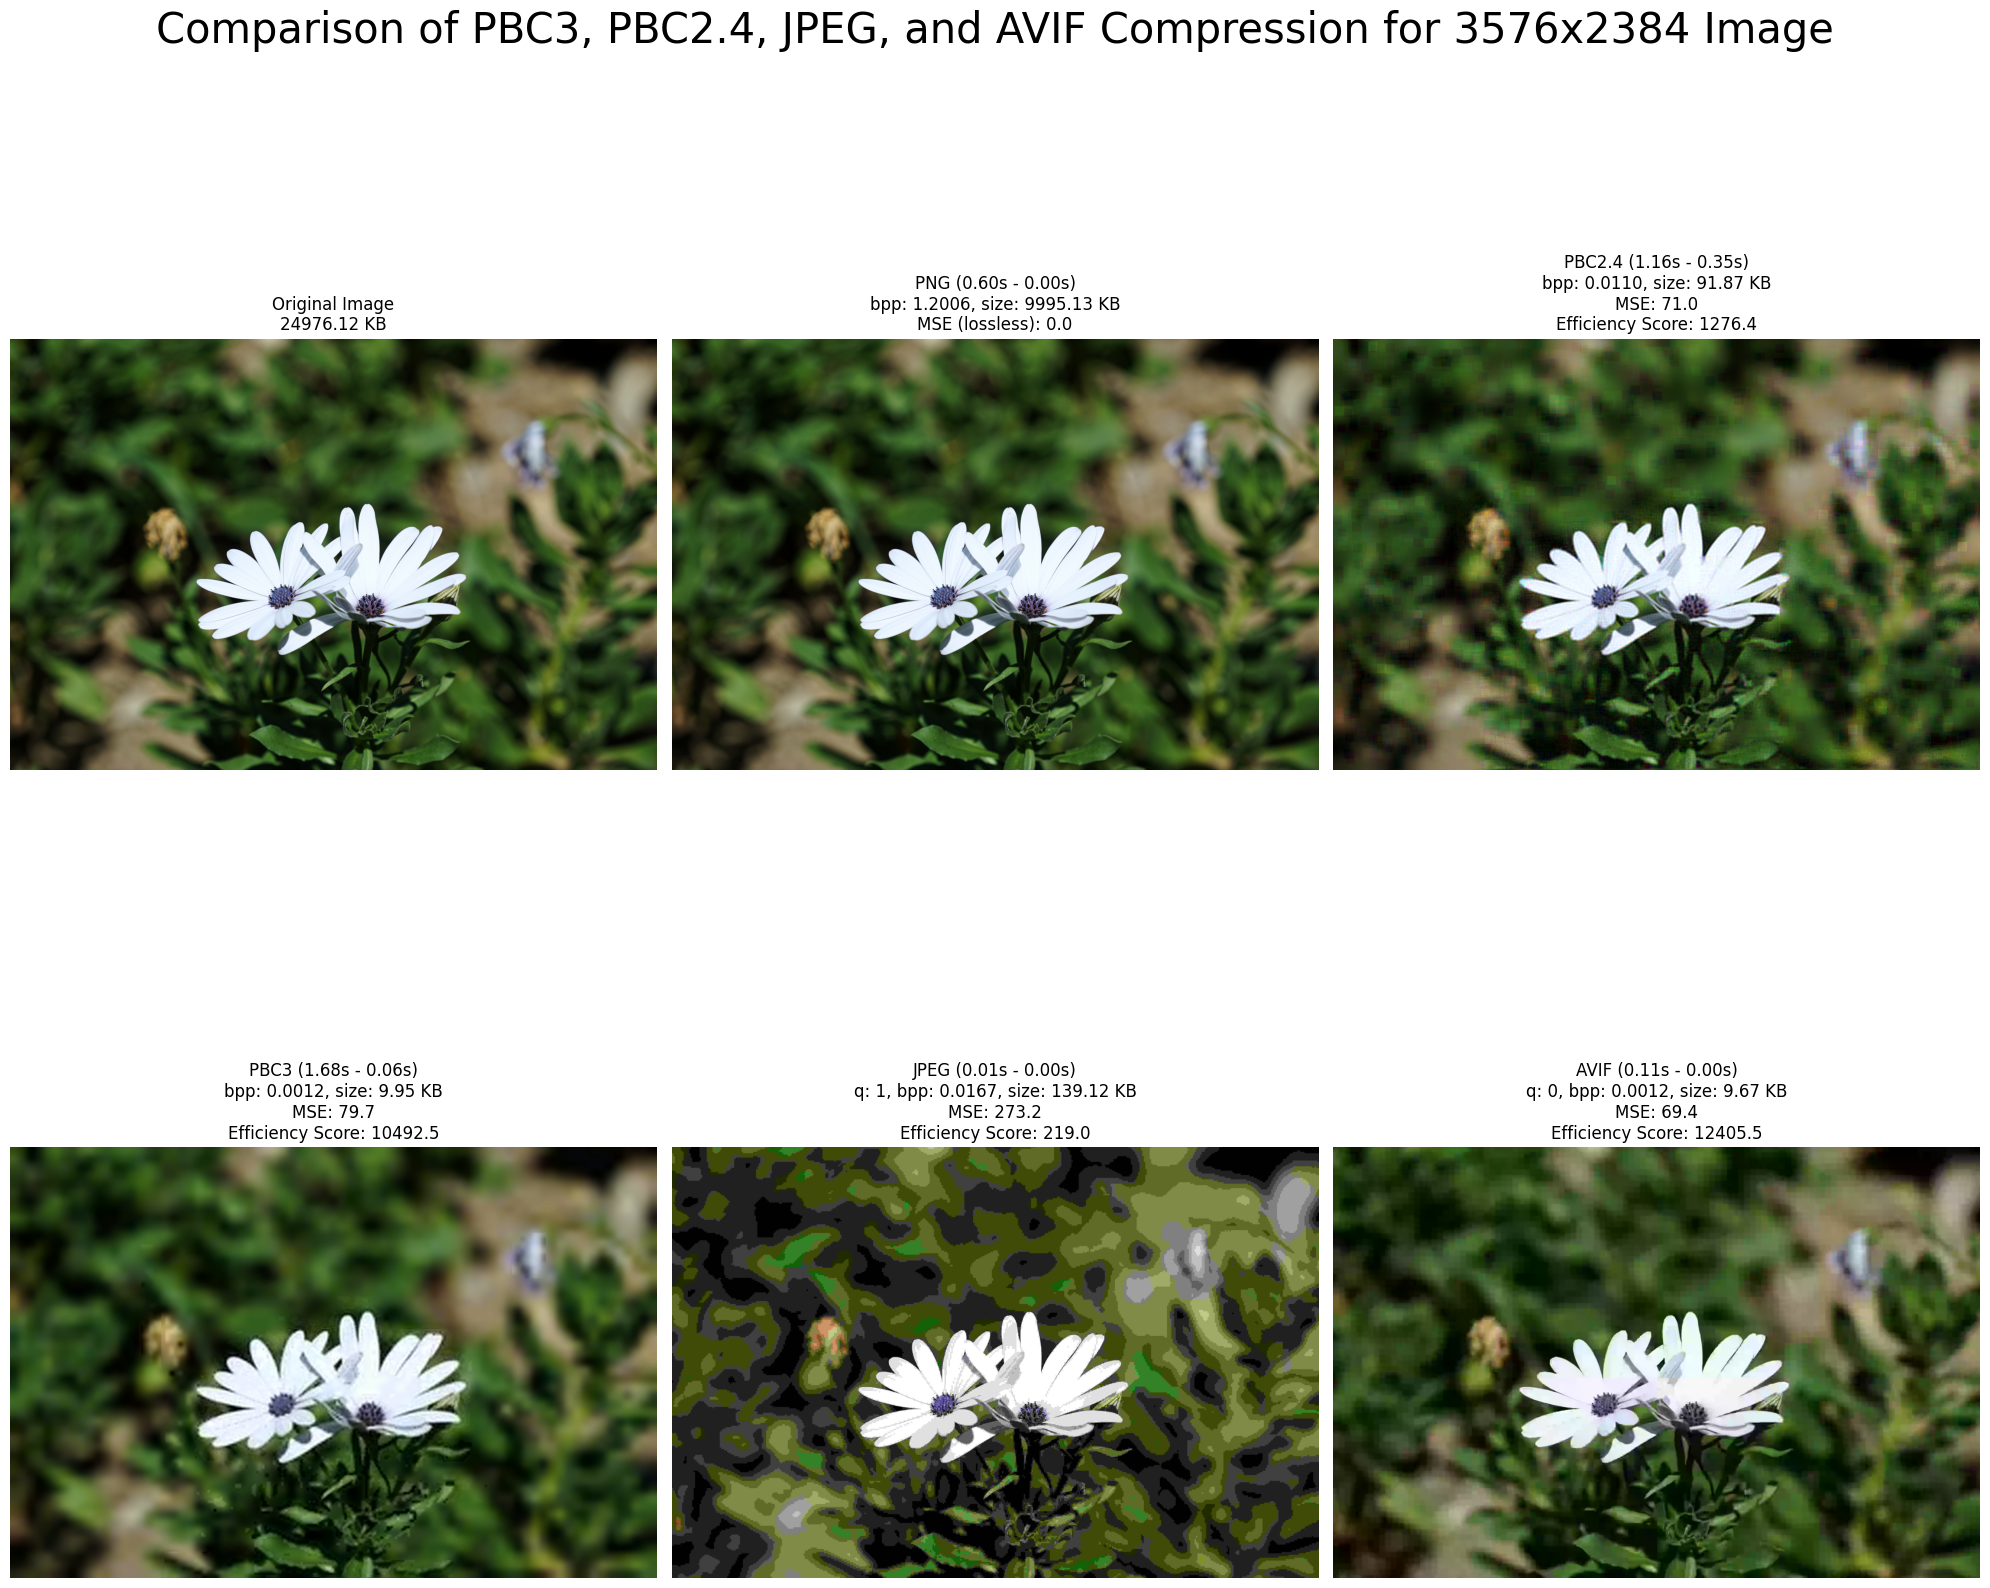

In [5]:
comparison_demo(img, res, search_count=5, show_png_too=True, figsize=(20, 20), tight_layout=True, suptitle_fontsize=30, suptitle_y=0.96)

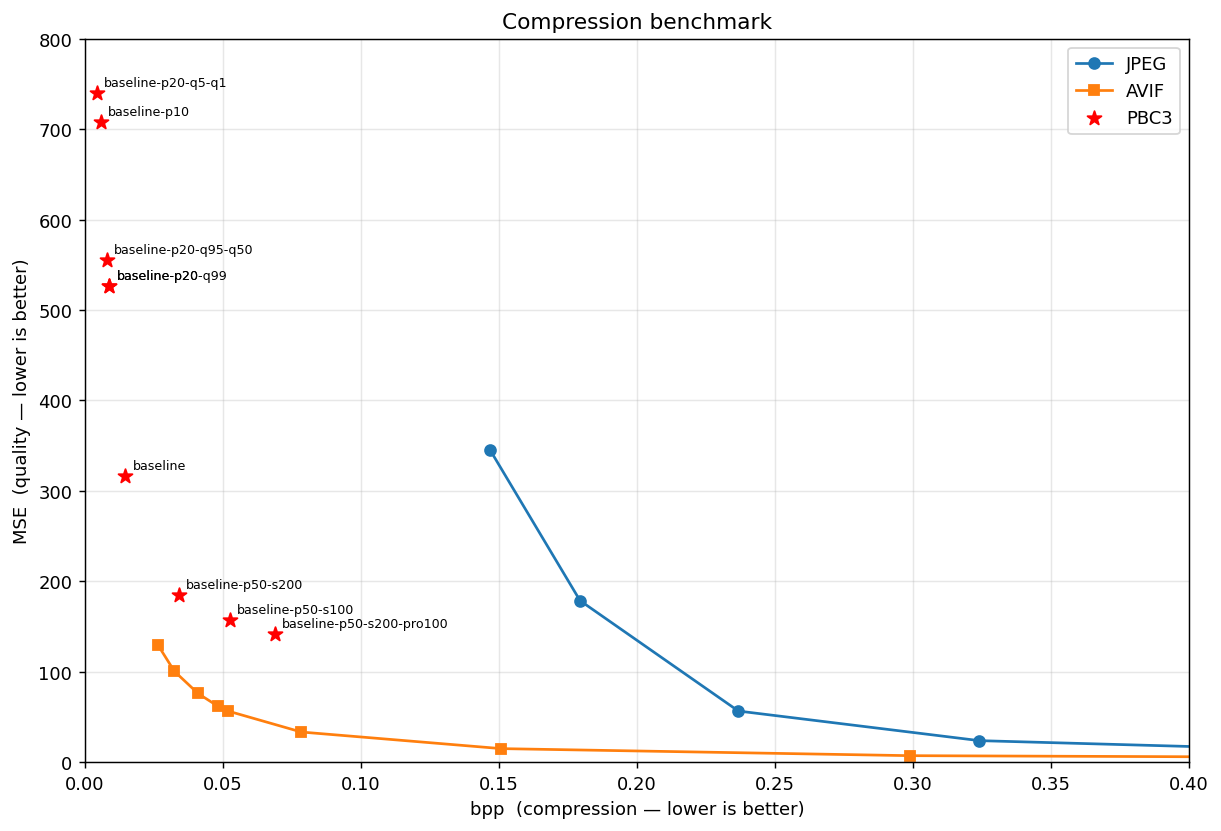

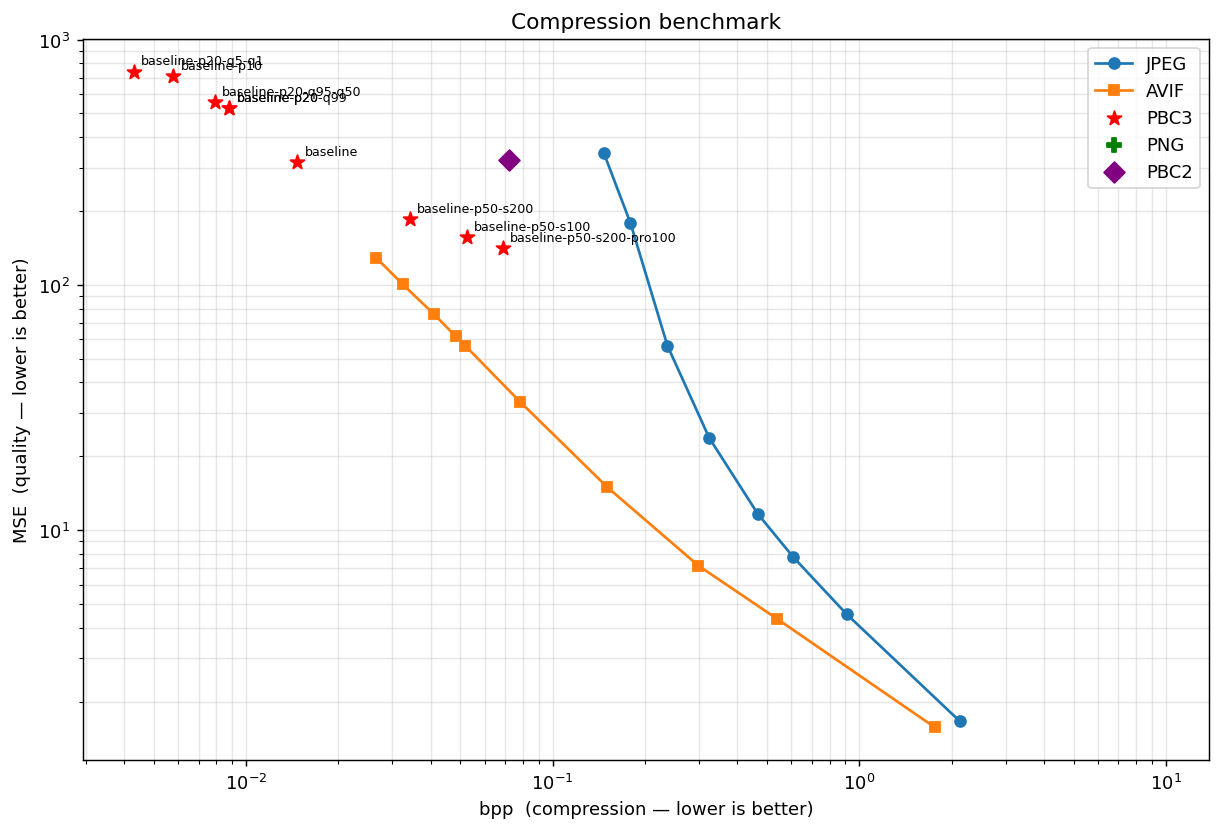

In [118]:
from benchmark_plot import plot_benchmark
bench_name = "bench_ducklings"


# only the lossy codecs, zoomed to a useful range
plot_benchmark(f"{bench_name}_summary.csv", include=("JPEG","AVIF","PBC3"),
               xlim=(0,0.4), ylim=(0,800), yscale="linear")#, out_path="zoom.png")

# everything, log-log
plot_benchmark(f"{bench_name}_summary.csv", xscale="log", yscale="log")